# 04 — Gene-level transition analysis

Identifies the **gene programs** underlying each disease transition in the
PLP relapsing-remitting EAE model.

Building on:
- **Notebook 01**: Novae spatial embeddings and niche aggregation
- **Notebook 02**: Attention-based transition model and transition vectors
- **Notebook 03**: Compartment-level transition dynamics (lesion (APC) expands at
  peak 1, lipid/ECM macrophage at peak 2, foamy macrophage at peak 3)

This notebook asks: what are the **molecular programs** behind those spatial shifts?

**Key findings**:
- Each disease peak is driven by a distinct macrophage program:
  Peak 1 = IFN-gamma/antigen presentation, Peak 2 = lipid processing,
  Peak 3 = foam cell/Trem2 pathology
- Remission is not passive — it involves active re-engagement of circadian/
  anti-inflammatory programs (`Nr1d1`, `Dbp`) and immune checkpoints (`Lag3`)
- The core clock oscillator (`Arntl`, `Clock`) persists through peaks while
  its anti-inflammatory output is selectively suppressed — consistent with
  NF-kB-mediated clock disruption


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../src")

import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from scipy import sparse
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

from temporal_foundation.config import (
    MODELS, STAGE_KEY, MODEL_KEY, REGION_KEY, SAMPLE_KEY,
    EmbeddingConfig, AggregationConfig,
    get_all_stages, get_transition_pairs, model_short_name,
)
from temporal_foundation.embeddings import load_embeddings
from temporal_foundation.aggregation import aggregate_all_samples, summarize_representations

## 1. Load embedded data and build niche representations

Load the per-sample h5ad files from notebook 01 (contain both gene expression
AND Novae embeddings + domain assignments).

In [2]:
EMBEDDED_DIR = Path("../data/embedded")

embed_config = EmbeddingConfig()
samples = load_embeddings(EMBEDDED_DIR, embed_config)

# Detect key names from first sample
s = next(iter(samples.values()))
novae_obsm = [k for k in s.obsm.keys() if 'novae' in k.lower()]
latent_key = novae_obsm[0] if novae_obsm else embed_config.latent_key

domain_key = "novae_domains"
if domain_key not in s.obs.columns:
    novae_obs = [c for c in s.obs.columns if 'novae_domain' in c.lower()]
    domain_key = novae_obs[0] if novae_obs else embed_config.domain_key

print(f"Loaded {len(samples)} samples")
print(f"Latent key: {latent_key} (dim={s.obsm[latent_key].shape[1]})")
print(f"Domain key: {domain_key} ({s.obs[domain_key].nunique()} domains)")
print(f"Gene expression: {s.X.shape[1]} genes, sparse={sparse.issparse(s.X)}")

Loaded 107 embedded samples

Loaded 107 samples
Latent key: novae_latent (dim=64)
Domain key: novae_domains (10 domains)
Gene expression: 5101 genes, sparse=True


In [3]:
# Aggregate to niche level
agg_config = AggregationConfig(
    method="spatial_domains",
    domain_key=domain_key,
    embedding_key=latent_key,
    include_composition=True,
    cell_type_key="anno_L2",
)

representations = aggregate_all_samples(samples, agg_config)
rep_lookup = {r.sample_id: r for r in representations}
summary = summarize_representations(representations)
print(f"\n{len(representations)} samples, {summary['n_niches'].sum()} total niches")

Aggregated 107 samples

Total niches: 1070 (avg 10 per sample)


107 samples, 1070 total niches


In [4]:
# Build sample-level embeddings and transition pairs (reproduced from nb02)

sample_data = []
for rep in representations:
    sample_data.append({
        "sample_id": rep.sample_id,
        "model": rep.model,
        "stage": rep.stage,
        "region": rep.region,
        "n_niches": rep.n_niches,
        "embedding": rep.embeddings.mean(axis=0),
    })

sample_df = pd.DataFrame(sample_data)

# Stage means (targets for transition model)
stage_means = {}
for _, row in sample_df.iterrows():
    key = (row["model"], row["stage"])
    if key not in stage_means:
        stage_means[key] = []
    stage_means[key].append(row["embedding"])
stage_means = {k: np.mean(v, axis=0) for k, v in stage_means.items()}

# Build training pairs
train_pairs = []
for model_name in ["MOG", "PLP"]:
    for from_stage, to_stage in get_transition_pairs(model_name):
        k_to = (model_name, to_stage)
        if k_to not in stage_means:
            continue
        target = stage_means[k_to]
        from_mask = (sample_df["model"] == model_name) & (sample_df["stage"] == from_stage)
        for idx in sample_df[from_mask].index:
            train_pairs.append({
                "model": model_name,
                "from_stage": from_stage,
                "to_stage": to_stage,
                "sample_id": sample_df.loc[idx, "sample_id"],
                "source": sample_df.loc[idx, "embedding"],
                "target": target,
            })

train_df = pd.DataFrame(train_pairs)
print(f"Training pairs: {len(train_df)}")
print(train_df.groupby(["model", "from_stage", "to_stage"]).size())

Training pairs: 88
model  from_stage  to_stage  
MOG    MOG CFA     NONSYMPTOM     6
       NONSYMPTOM  OS1            6
       OS1         PEAK1          8
       PEAK1       LONG           6
PLP    MONOPHASIC  PEAK1         12
       ONSET1      ONSET2         6
       ONSET2      MONOPHASIC     6
       PEAK1       REMISSION1     9
       PEAK2       REMISSION2     9
       PLP CFA     ONSET1         9
       REMISSION1  PEAK2          8
       REMISSION2  PEAK3          3
dtype: int64


## 2. Train attention transition model

Reproduced from notebook 02. The attention weights over niches tell us which
spatial neighborhoods are most informative for predicting transitions.

In [5]:
class NicheAttentionTransitionModel(nn.Module):
    """Attention-based transition model operating on niche-level embeddings."""
    
    def __init__(self, embed_dim, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.transition = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
        )
    
    def forward(self, niche_embeddings):
        attn_logits = self.attention(niche_embeddings).squeeze(-1)
        attn_weights = torch.softmax(attn_logits, dim=0)
        sample_repr = (attn_weights.unsqueeze(-1) * niche_embeddings).sum(dim=0)
        predicted = self.transition(sample_repr)
        return predicted, attn_weights

In [6]:
# Build niche-level training data
niche_train_data = []

for _, row in train_df.iterrows():
    sample_id = row["sample_id"]
    if sample_id not in rep_lookup:
        continue
    rep = rep_lookup[sample_id]
    niche_train_data.append({
        "sample_id": sample_id,
        "model": row["model"],
        "from_stage": row["from_stage"],
        "to_stage": row["to_stage"],
        "niche_embeddings": torch.tensor(rep.embeddings, dtype=torch.float32),
        "niche_ids": rep.niche_ids,
        "target": torch.tensor(row["target"], dtype=torch.float32),
        "niche_centroids": rep.centroids,
        "niche_cell_counts": rep.cell_counts,
    })

print(f"Niche-level training examples: {len(niche_train_data)}")
embed_dim = niche_train_data[0]["niche_embeddings"].shape[1]
print(f"Embedding dim: {embed_dim}")

Niche-level training examples: 88
Embedding dim: 64


Epoch 100/500  loss=0.000042
Epoch 200/500  loss=0.000042
Epoch 300/500  loss=0.000040
Epoch 400/500  loss=0.000043
Epoch 500/500  loss=0.000042


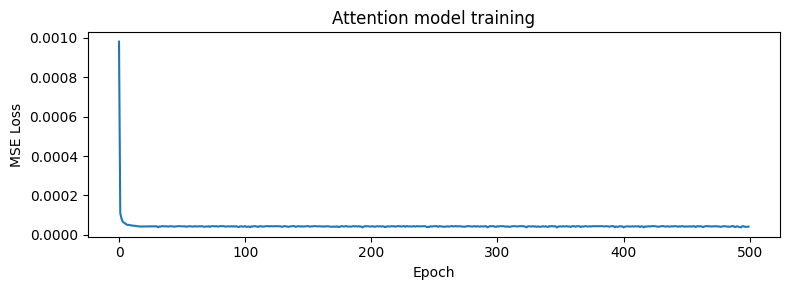

In [7]:
# Train
attn_model = NicheAttentionTransitionModel(embed_dim=embed_dim, hidden_dim=64, dropout=0.1)
optimizer = torch.optim.Adam(attn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

n_epochs = 500
losses = []

attn_model.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    for example in niche_train_data:
        optimizer.zero_grad()
        pred, _ = attn_model(example["niche_embeddings"])
        loss = criterion(pred, example["target"])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(niche_train_data)
    losses.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  loss={epoch_loss:.6f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Attention model training")
plt.tight_layout()
plt.show()

In [8]:
# Extract attention weights for all training examples
attn_model.eval()
attention_results = []

with torch.no_grad():
    for example in niche_train_data:
        pred, attn_weights = attn_model(example["niche_embeddings"])
        attention_results.append({
            "sample_id": example["sample_id"],
            "model": example["model"],
            "from_stage": example["from_stage"],
            "to_stage": example["to_stage"],
            "attention_weights": attn_weights.numpy(),
            "niche_ids": example["niche_ids"],
            "niche_centroids": example["niche_centroids"],
            "niche_cell_counts": example["niche_cell_counts"],
        })

print(f"Extracted attention for {len(attention_results)} samples")

# Verify coverage per transition
from collections import Counter
trans_counts = Counter((r["model"], r["from_stage"], r["to_stage"]) for r in attention_results)
for (m, f, t), n in sorted(trans_counts.items()):
    print(f"  {m} {f:15s} -> {t:15s}: {n} samples")


Extracted attention for 88 samples
  MOG MOG CFA         -> NONSYMPTOM     : 6 samples
  MOG NONSYMPTOM      -> OS1            : 6 samples
  MOG OS1             -> PEAK1          : 8 samples
  MOG PEAK1           -> LONG           : 6 samples
  PLP MONOPHASIC      -> PEAK1          : 12 samples
  PLP ONSET1          -> ONSET2         : 6 samples
  PLP ONSET2          -> MONOPHASIC     : 6 samples
  PLP PEAK1           -> REMISSION1     : 9 samples
  PLP PEAK2           -> REMISSION2     : 9 samples
  PLP PLP CFA         -> ONSET1         : 9 samples
  PLP REMISSION1      -> PEAK2          : 8 samples
  PLP REMISSION2      -> PEAK3          : 3 samples


## 3. Cell-level gene signatures of disease transitions

With ~3 biological replicates per stage, pseudobulk DE has no power over 5,000
genes. Instead, leverage the full cell count:

**A. Stage marker genes**: rank_genes_groups on all PLP cells grouped by stage.
Shows what genes define each disease state.

**B. Compartment marker genes**: what gene programs do the compartments represent?
Combined with notebook 03's compartment dynamics, this translates spatial shifts
to molecular programs.

**C. Within-compartment stage DE**: do cells in the same compartment change gene
expression across stages? E.g., lesion (APC) at PEAK1 vs REMISSION1.


### Why cell-level DE instead of pseudobulk?

With ~3 biological replicates per stage, pseudobulk DE (aggregating to sample
level) has no statistical power across 5,000 genes — nothing survives FDR
correction. Cell-level DE (scanpy `rank_genes_groups`) leverages the full
~600k PLP cells. This is standard in the spatial transcriptomics field.
The trade-off is pseudoreplication (cells within a sample are not independent),
so we treat the results as descriptive gene signatures rather than strict
hypothesis tests.


In [9]:
# Load the full dataset (not per-sample embedded files) for cell-level DE
from temporal_foundation.data import load_adata

adata_full = load_adata()

# Add short model name
adata_full.obs["model_short"] = adata_full.obs[MODEL_KEY].map(model_short_name)

COMPARTMENT_KEY = "compartment_mana"
print(f"Full dataset: {adata_full.n_obs:,} cells, {adata_full.n_vars} genes")
print(f"Compartments: {adata_full.obs[COMPARTMENT_KEY].nunique()}")
print(f"Stages: {adata_full.obs[STAGE_KEY].nunique()}")


Loading /Volumes/processing2/RRmap/data/rrmap.companion.ready.h5ad...

Loaded 877,141 cells, 5101 genes, 107 samples

Full dataset: 877,141 cells, 5101 genes
Compartments: 15
Stages: 13


In [10]:
# --- A. Stage marker genes for PLP ---
# What genes define each disease state?

plp = adata_full[adata_full.obs["model_short"] == "PLP"].copy()
print(f"PLP cells: {plp.n_obs:,}")

# Normalize for DE
sc.pp.normalize_total(plp, target_sum=1e4)
sc.pp.log1p(plp)

# Order stages for sensible comparisons
plp_stages = get_all_stages()["PLP"]
plp.obs[STAGE_KEY] = pd.Categorical(plp.obs[STAGE_KEY], categories=plp_stages, ordered=True)

sc.tl.rank_genes_groups(plp, groupby=STAGE_KEY, method="wilcoxon", n_genes=50)

# Show top markers per stage
for stage in plp_stages:
    try:
        result = sc.get.rank_genes_groups_df(plp, group=stage)
        top = result[result["pvals_adj"] < 0.05].head(10)
        if len(top) > 0:
            print(f"\n{stage} markers ({len(result[result['pvals_adj'] < 0.05])} sig total):")
            for _, row in top.iterrows():
                print(f"  {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}  padj={row['pvals_adj']:.1e}")
    except Exception as e:
        print(f"\n{stage}: {e}")


PLP cells: 608,429


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



PLP CFA markers (50 sig total):
  Gprc5b           log2fc=+1.06  padj=0.0e+00
  Dpysl2           log2fc=+0.73  padj=0.0e+00
  Gabbr1           log2fc=+0.86  padj=0.0e+00
  Trim2            log2fc=+0.99  padj=0.0e+00
  Nr1d1            log2fc=+1.24  padj=0.0e+00
  Spock3           log2fc=+1.23  padj=0.0e+00
  Fasn             log2fc=+0.86  padj=0.0e+00
  Mapk8ip1         log2fc=+0.84  padj=0.0e+00
  Kif1b            log2fc=+0.74  padj=0.0e+00
  Msmo1            log2fc=+1.03  padj=0.0e+00

ONSET1 markers (50 sig total):
  Sez6l2           log2fc=+0.84  padj=0.0e+00
  Aplp1            log2fc=+0.60  padj=0.0e+00
  Gnao1            log2fc=+0.59  padj=0.0e+00
  Msmo1            log2fc=+0.89  padj=0.0e+00
  Sv2a             log2fc=+0.66  padj=0.0e+00
  Zbtb16           log2fc=+0.98  padj=0.0e+00
  Mapt             log2fc=+0.47  padj=0.0e+00
  Srebf2           log2fc=+0.53  padj=0.0e+00
  Atp2a2           log2fc=+0.25  padj=0.0e+00
  Aldoc            log2fc=+0.46  padj=0.0e+00

ONSET2 markers

### B. Compartment marker genes

What gene programs define each spatial compartment? This is the key bridge
between the compartment dynamics (notebook 03) and molecular mechanisms.

When notebook 03 showed that *lesion (APC)* expands at PEAK1, we now ask:
what genes define that compartment? Those genes ARE the molecular program
being activated at that transition.


In [11]:
# --- B. Compartment marker genes ---
# What gene programs define each compartment?
# This translates the compartment dynamics from notebook 03 into gene programs.

# Use the full (non-PLP-specific) dataset for compartment markers
adata_norm = adata_full.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

# Drop cells without compartment annotation
mask = adata_norm.obs[COMPARTMENT_KEY].notna()
adata_comp = adata_norm[mask].copy()
print(f"Cells with compartment labels: {adata_comp.n_obs:,}")

sc.tl.rank_genes_groups(adata_comp, groupby=COMPARTMENT_KEY, method="wilcoxon", n_genes=20)

# Show top markers for key compartments
key_compartments = [
    "lesion (APC)",
    "lesion (lipid/ECM macrophage)",
    "lesion (Foamy-lipid droplet)",
    "lesion (reactive glia)",
    "lesion (T cell nodules)",
    "white matter",
    "grey matter",
]

compartment_markers = {}
for comp in key_compartments:
    try:
        result = sc.get.rank_genes_groups_df(adata_comp, group=comp)
        sig = result[result["pvals_adj"] < 0.05]
        compartment_markers[comp] = sig
        top = sig.head(10)
        print(f"\n'{comp}' markers ({len(sig)} sig):")
        for _, row in top.iterrows():
            print(f"  {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}  padj={row['pvals_adj']:.1e}")
    except Exception as e:
        print(f"\n'{comp}': {e}")


Cells with compartment labels: 877,141

'lesion (APC)' markers (20 sig):
  Psmb8            log2fc=+2.60  padj=0.0e+00
  Ctss             log2fc=+2.60  padj=0.0e+00
  Cd74             log2fc=+2.69  padj=0.0e+00
  H2-Ab1           log2fc=+3.07  padj=0.0e+00
  H2-K1            log2fc=+1.86  padj=0.0e+00
  Spi1             log2fc=+2.97  padj=0.0e+00
  H2-Aa            log2fc=+2.94  padj=0.0e+00
  Cd300lf          log2fc=+3.62  padj=0.0e+00
  Ncf1             log2fc=+3.02  padj=0.0e+00
  Syk              log2fc=+3.30  padj=0.0e+00

'lesion (lipid/ECM macrophage)' markers (20 sig):
  H2-D1            log2fc=+1.72  padj=0.0e+00
  Cd74             log2fc=+2.29  padj=0.0e+00
  Ctss             log2fc=+2.00  padj=0.0e+00
  Grn              log2fc=+1.82  padj=0.0e+00
  Abca1            log2fc=+2.33  padj=0.0e+00
  H2-Aa            log2fc=+2.29  padj=0.0e+00
  B2m              log2fc=+0.79  padj=0.0e+00
  H2-Ab1           log2fc=+1.83  padj=0.0e+00
  Gpnmb            log2fc=+2.64  padj=0.0e+00
  

### Connecting compartment markers to transition dynamics

From notebook 03 we know:
- PEAK1 is dominated by expanding **lesion (APC)** compartment
- PEAK2 by **lesion (lipid/ECM macrophage)**
- PEAK3 by **lesion (Foamy-lipid droplet)**

The marker genes above tell us what molecular programs each of these represents.
APC lesion markers = the gene program activated at peak 1, etc.


### C. Within-compartment stage DE

A complementary question: do cells **within the same compartment** change gene
expression across stages? For example, are APC lesion cells at PEAK1
molecularly different from APC lesion cells at REMISSION1?

This controls for cell type composition (same compartment) and isolates
stage-dependent transcriptional changes within a spatial context.


In [12]:
# --- C. Within-compartment stage DE ---
# How do cells WITHIN the same compartment change across stages?
# This controls for cell type composition and asks about state changes.

within_comp_queries = [
    ("lesion (APC)", "PEAK1", "REMISSION1",
     "APC lesion cells: peak vs remission"),
    ("lesion (lipid/ECM macrophage)", "PEAK2", "REMISSION2",
     "Lipid/ECM lesion cells: peak vs remission"),
    ("white matter", "PEAK1", "REMISSION1",
     "White matter cells: peak vs remission"),
    ("grey matter", "MONOPHASIC", "PEAK1",
     "Grey matter cells: pre-peak vs peak"),
]

within_de_results = {}

for comp, stage_a, stage_b, desc in within_comp_queries:
    print(f"\n{'='*60}")
    print(f"{desc}")
    print(f"{'='*60}")
    
    mask = (
        (adata_norm.obs[COMPARTMENT_KEY] == comp)
        & (adata_norm.obs["model_short"] == "PLP")
        & (adata_norm.obs[STAGE_KEY].isin([stage_a, stage_b]))
    )
    sub = adata_norm[mask].copy()
    
    n_a = (sub.obs[STAGE_KEY] == stage_a).sum()
    n_b = (sub.obs[STAGE_KEY] == stage_b).sum()
    print(f"  {stage_a}: {n_a:,} cells, {stage_b}: {n_b:,} cells")
    
    if n_a < 50 or n_b < 50:
        print("  Skipped: too few cells")
        continue
    
    sub.obs[STAGE_KEY] = pd.Categorical(
        sub.obs[STAGE_KEY], categories=[stage_a, stage_b]
    )
    
    sc.tl.rank_genes_groups(sub, groupby=STAGE_KEY, groups=[stage_b],
                            reference=stage_a, method="wilcoxon", n_genes=sub.n_vars)
    
    result = sc.get.rank_genes_groups_df(sub, group=stage_b)
    sig = result[result["pvals_adj"] < 0.05]
    within_de_results[(comp, stage_a, stage_b)] = result
    
    n_up = (sig["logfoldchanges"] > 0).sum()
    n_down = (sig["logfoldchanges"] < 0).sum()
    print(f"  DE genes: {len(sig)} significant ({n_up} up at {stage_b}, {n_down} down)")
    
    if len(sig) > 0:
        print(f"\n  Upregulated at {stage_b}:")
        for _, row in sig[sig["logfoldchanges"] > 0].head(15).iterrows():
            print(f"    {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}  padj={row['pvals_adj']:.1e}")
        print(f"\n  Downregulated at {stage_b}:")
        for _, row in sig[sig["logfoldchanges"] < 0].sort_values("logfoldchanges").head(15).iterrows():
            print(f"    {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}  padj={row['pvals_adj']:.1e}")



APC lesion cells: peak vs remission
  PEAK1: 16,664 cells, REMISSION1: 2,495 cells
  DE genes: 1064 significant (729 up at REMISSION1, 335 down)

  Upregulated at REMISSION1:
    Ighm             log2fc=+1.86  padj=9.1e-91
    Ndrg2            log2fc=+1.23  padj=5.6e-78
    Siglech          log2fc=+2.13  padj=4.5e-59
    Fyn              log2fc=+1.08  padj=3.6e-53
    Flt3             log2fc=+2.12  padj=7.0e-44
    Ckb              log2fc=+0.96  padj=4.7e-42
    Cd180            log2fc=+1.27  padj=7.5e-40
    Kcnj10           log2fc=+0.99  padj=3.4e-37
    Ccnd1            log2fc=+0.87  padj=7.2e-36
    Gfap             log2fc=+0.64  padj=2.3e-35
    Bcl11a           log2fc=+2.08  padj=2.8e-35
    Cyfip2           log2fc=+0.88  padj=1.1e-33
    Cdh1             log2fc=+1.86  padj=1.9e-33
    Slc9a9           log2fc=+1.38  padj=1.5e-32
    Mbnl1            log2fc=+0.86  padj=1.7e-32

  Downregulated at REMISSION1:
    Ly6i             log2fc=-2.21  padj=3.0e-199
    Fpr1             lo

## 4. Genes correlated with transition direction in embedding space

A complementary, embedding-guided approach: for each gene, compute its
correlation with the sample's projection along the **transition vector**
from notebook 02.

Samples that are farther along the transition direction (closer to the next
stage in Novae embedding space) should have higher/lower expression of
transition-relevant genes. This finds genes that track the spatial trajectory.

*Note*: with few samples per stage, statistical power is limited. Treat these
as candidate genes to cross-reference with the cell-level DE above.


In [13]:
# Compute transition vectors (direction of change in embedding space)
transition_vectors = {}
for model_name in ["MOG", "PLP"]:
    for from_s, to_s in get_transition_pairs(model_name):
        k1, k2 = (model_name, from_s), (model_name, to_s)
        if k1 in stage_means and k2 in stage_means:
            vec = stage_means[k2] - stage_means[k1]
            vec = vec / (np.linalg.norm(vec) + 1e-10)
            transition_vectors[(model_name, from_s, to_s)] = vec

print(f"Computed {len(transition_vectors)} transition vectors")

Computed 12 transition vectors


In [14]:
# Build sample-level pseudobulk
gene_names = next(iter(samples.values())).var_names

def pseudobulk_for_sample(adata):
    if sparse.issparse(adata.X):
        counts = np.asarray(adata.X.sum(axis=0)).flatten()
    else:
        counts = adata.X.sum(axis=0).flatten()
    total = counts.sum()
    if total > 0:
        return np.log1p(counts / total * 1e6)
    return counts

pb_lookup = {sid: pseudobulk_for_sample(adata) for sid, adata in samples.items()}
print(f"Pseudobulk computed for {len(pb_lookup)} samples")

Pseudobulk computed for 107 samples


In [35]:
def gene_transition_correlation(sample_df, pb_lookup, model_name, from_stage,
                                to_stage, transition_vectors, gene_names, alpha=0.05):
    """Correlate each gene's expression with projection along transition vector.
    
    Uses samples from BOTH stages — genes that increase along the transition
    direction will be positively correlated.
    """
    tvec = transition_vectors.get((model_name, from_stage, to_stage))
    if tvec is None:
        return None
    
    mask = (
        (sample_df["model"] == model_name)
        & (sample_df["stage"].isin([from_stage, to_stage]))
    )
    relevant = sample_df[mask]
    
    projections, expressions = [], []
    for _, row in relevant.iterrows():
        sid = row["sample_id"]
        if sid not in pb_lookup:
            continue
        projections.append(np.dot(row["embedding"], tvec))
        expressions.append(pb_lookup[sid])
    
    if len(projections) < 4:
        return None
    
    projections = np.array(projections)
    expressions = np.vstack(expressions)
    
    results = []
    for i, gene in enumerate(gene_names):
        rho, pval = spearmanr(projections, expressions[:, i])
        results.append({"gene": gene, "spearman_rho": rho, "pval": pval})
    
    df = pd.DataFrame(results)
    reject, padj, _, _ = multipletests(df["pval"].fillna(1), method="fdr_bh")
    df["padj"] = padj
    df["significant"] = reject & (df["padj"] < alpha)
    return df.sort_values("pval")

In [36]:
key_transitions = [
    ("PLP", "MONOPHASIC", "PEAK1"),
    ("PLP", "PEAK1", "REMISSION1"),
    ("PLP", "REMISSION1", "PEAK2"),
    ("PLP", "PEAK2", "REMISSION2"),
    ("PLP", "REMISSION2", "PEAK3"),
    ("MOG", "PEAK1", "LONG"),
]

corr_results = {}

for model_name, from_s, to_s in key_transitions:
    print(f"\n{'='*60}")
    print(f"{model_name}: {from_s} -> {to_s}")
    print(f"Genes correlated with transition direction in embedding space:")
    print(f"{'='*60}")
    
    df = gene_transition_correlation(
        sample_df, pb_lookup, model_name, from_s, to_s,
        transition_vectors, gene_names
    )
    
    if df is None:
        print("  Skipped: too few samples")
        continue
    
    corr_results[(model_name, from_s, to_s)] = df
    sig = df[df["significant"]]
    n_pos = (sig["spearman_rho"] > 0).sum()
    n_neg = (sig["spearman_rho"] < 0).sum()
    print(f"  Significant: {len(sig)} genes ({n_pos} positive, {n_neg} negative)")
    
    if len(sig) > 0:
        print(f"\n  Top positive (increase along transition):")
        for _, row in sig.nlargest(10, "spearman_rho").iterrows():
            print(f"    {row['gene']:15s}  rho={row['spearman_rho']:+.3f}  padj={row['padj']:.2e}")
        print(f"\n  Top negative (decrease along transition):")
        for _, row in sig.nsmallest(10, "spearman_rho").iterrows():
            print(f"    {row['gene']:15s}  rho={row['spearman_rho']:+.3f}  padj={row['padj']:.2e}")
    else:
        print(f"\n  No genes pass FDR. Top by raw correlation:")
        for _, row in df.nlargest(10, "spearman_rho").iterrows():
            print(f"    {row['gene']:15s}  rho={row['spearman_rho']:+.3f}  p={row['pval']:.2e}")


PLP: MONOPHASIC -> PEAK1
Genes correlated with transition direction in embedding space:
  Significant: 2443 genes (1050 positive, 1393 negative)

  Top positive (increase along transition):
    Slc31a1          rho=+0.894  padj=2.52e-04
    Actn1            rho=+0.871  padj=4.61e-04
    Atp7a            rho=+0.871  padj=4.61e-04
    Cers6            rho=+0.866  padj=4.93e-04
    Frrs1            rho=+0.851  padj=5.85e-04
    Derl2            rho=+0.851  padj=5.85e-04
    Tnfrsf11a        rho=+0.840  padj=5.97e-04
    Msr1             rho=+0.838  padj=5.97e-04
    Alox5            rho=+0.832  padj=5.97e-04
    Kif4             rho=+0.832  padj=5.97e-04

  Top negative (decrease along transition):
    Col9a2           rho=-0.858  padj=5.85e-04
    Lrig1            rho=-0.856  padj=5.85e-04
    Whrn             rho=-0.853  padj=5.85e-04
    Chrm1            rho=-0.848  padj=5.97e-04
    Bdh1             rho=-0.844  padj=5.97e-04
    Aif1l            rho=-0.838  padj=5.97e-04
    Gatd3a  

## 5. Expanding vs contracting Novae domain gene programs

Using the Novae spatial domain assignments from notebook 01: which domains
grow (gain cells) and which shrink across each transition?

Compare gene expression between expanding and contracting domains **at the
FROM stage** — what's molecularly different about niches that are about to
expand? This bridges the Novae embedding structure with gene expression.

*Note*: same small-N caveat as section 4. The cell-level results from
section 3 are the most reliable gene-level findings.


In [37]:
def domain_dynamics(representations, model_name, from_stage, to_stage):
    """Identify which Novae domains expand or contract across a transition."""
    from_reps = [r for r in representations if r.model == model_name and r.stage == from_stage]
    to_reps = [r for r in representations if r.model == model_name and r.stage == to_stage]
    
    if not from_reps or not to_reps:
        return None
    
    def domain_proportions(reps):
        all_props = {}
        for rep in reps:
            total = rep.cell_counts.sum()
            for nid, count in zip(rep.niche_ids, rep.cell_counts):
                nid = str(nid)
                if nid not in all_props:
                    all_props[nid] = []
                all_props[nid].append(count / total)
        return {k: np.mean(v) for k, v in all_props.items()}
    
    props_from = domain_proportions(from_reps)
    props_to = domain_proportions(to_reps)
    
    all_domains = sorted(set(props_from.keys()) | set(props_to.keys()))
    rows = []
    for d in all_domains:
        pf = props_from.get(d, 0)
        pt = props_to.get(d, 0)
        rows.append({"domain": d, "prop_from": pf, "prop_to": pt, "delta": pt - pf})
    
    return pd.DataFrame(rows).sort_values("delta", key=abs, ascending=False)


def expanding_vs_contracting_de(samples_dict, representations, model_name,
                                 from_stage, to_stage, domain_key, n_top=3, alpha=0.05):
    """DE between cells in expanding vs contracting domains at the FROM stage."""
    dynamics = domain_dynamics(representations, model_name, from_stage, to_stage)
    if dynamics is None:
        return None, None
    
    expanding = set(dynamics.nlargest(n_top, "delta")["domain"])
    contracting = set(dynamics.nsmallest(n_top, "delta")["domain"])
    
    from_reps = [r for r in representations if r.model == model_name and r.stage == from_stage]
    from_sids = {r.sample_id for r in from_reps}
    
    gene_names = next(iter(samples_dict.values())).var_names
    expand_profiles, contract_profiles = [], []
    
    for sid in from_sids:
        if sid not in samples_dict:
            continue
        adata = samples_dict[sid]
        domains = adata.obs[domain_key].astype(str).values
        
        for target_set, profiles in [(expanding, expand_profiles), (contracting, contract_profiles)]:
            mask = np.isin(domains, list(target_set))
            if mask.sum() >= 10:
                X = adata[mask].X
                if sparse.issparse(X):
                    counts = np.asarray(X.sum(axis=0)).flatten()
                else:
                    counts = X.sum(axis=0).flatten()
                total = counts.sum()
                if total > 0:
                    profiles.append(np.log1p(counts / total * 1e6))
    
    if len(expand_profiles) < 2 or len(contract_profiles) < 2:
        return dynamics, None
    
    X_exp = np.vstack(expand_profiles)
    X_con = np.vstack(contract_profiles)
    
    results = []
    for i, gene in enumerate(gene_names):
        ve, vc = X_exp[:, i], X_con[:, i]
        log2fc = (ve.mean() - vc.mean()) / np.log(2)
        if (ve.std() + vc.std()) > 0:
            _, pval = mannwhitneyu(ve, vc, alternative="two-sided")
        else:
            pval = 1.0
        results.append({"gene": gene, "log2fc_expand_vs_contract": log2fc, "pval": pval})
    
    df = pd.DataFrame(results)
    reject, padj, _, _ = multipletests(df["pval"], method="fdr_bh")
    df["padj"] = padj
    df["significant"] = reject & (df["padj"] < alpha)
    return dynamics, df.sort_values("pval")

In [38]:
domain_de_results = {}

for model_name, from_s, to_s in key_transitions:
    print(f"\n{'='*60}")
    print(f"{model_name}: {from_s} -> {to_s}")
    print(f"{'='*60}")
    
    dynamics, de = expanding_vs_contracting_de(
        samples, representations, model_name, from_s, to_s, domain_key
    )
    
    if dynamics is not None:
        print("\n  Domain dynamics (top 5):")
        for _, row in dynamics.head(5).iterrows():
            direction = "+" if row["delta"] > 0 else "-"
            print(f"    domain {row['domain']:5s}  {row['prop_from']:.3f} -> {row['prop_to']:.3f}  "
                  f"({direction}{abs(row['delta']):.3f})")
    
    if de is None:
        print("\n  DE skipped: too few samples/cells in target domains")
        continue
    
    domain_de_results[(model_name, from_s, to_s)] = de
    sig = de[de["significant"]]
    print(f"\n  DE genes (expanding vs contracting): {len(sig)} significant")
    
    if len(sig) > 0:
        print(f"\n  Enriched in expanding domains:")
        for _, row in sig.nlargest(10, "log2fc_expand_vs_contract").iterrows():
            print(f"    {row['gene']:15s}  log2fc={row['log2fc_expand_vs_contract']:+.3f}  padj={row['padj']:.2e}")
        print(f"\n  Enriched in contracting domains:")
        for _, row in sig.nsmallest(10, "log2fc_expand_vs_contract").iterrows():
            print(f"    {row['gene']:15s}  log2fc={row['log2fc_expand_vs_contract']:+.3f}  padj={row['padj']:.2e}")


PLP: MONOPHASIC -> PEAK1

  Domain dynamics (top 5):
    domain D996   0.390 -> 0.017  (-0.374)
    domain D984   0.370 -> 0.000  (-0.370)
    domain D981   0.307 -> 0.000  (-0.307)
    domain D974   0.258 -> 0.000  (-0.258)
    domain D1000  0.003 -> 0.201  (+0.198)

  DE genes (expanding vs contracting): 0 significant

PLP: PEAK1 -> REMISSION1

  Domain dynamics (top 5):
    domain D994   0.119 -> 0.306  (+0.187)
    domain D1000  0.201 -> 0.036  (-0.165)
    domain D1005  0.007 -> 0.163  (+0.156)
    domain D1004  0.067 -> 0.219  (+0.152)
    domain D998   0.000 -> 0.133  (+0.133)

  DE genes (expanding vs contracting): 0 significant

PLP: REMISSION1 -> PEAK2

  Domain dynamics (top 5):
    domain D986   0.000 -> 0.313  (+0.313)
    domain D994   0.306 -> 0.008  (-0.298)
    domain D1004  0.219 -> 0.008  (-0.211)
    domain D1002  0.059 -> 0.264  (+0.206)
    domain D998   0.133 -> 0.001  (-0.132)

  DE skipped: too few samples/cells in target domains

PLP: PEAK2 -> REMISSION2

  D

## 6. MOG vs PLP at PEAK1 — embedding-stratified gene signatures

At PEAK1, MOG (chronic) and PLP (relapsing-remitting) tissue have similar
clinical severity but divergent futures. Using the Novae embeddings, we
identify **model-specific niches** — spatial neighborhoods that exist in one
model but not the other — and compare their gene expression.

Genes enriched in PLP-specific niches may represent pro-remission programs;
genes enriched in MOG-specific niches may represent pro-chronic programs.


In [39]:
from scipy.spatial.distance import cdist

# Get PEAK1 niche embeddings for both models
mog_peak_reps = [r for r in representations if r.model == "MOG" and r.stage == "PEAK1"]
plp_peak_reps = [r for r in representations if r.model == "PLP" and r.stage == "PEAK1"]

print(f"MOG PEAK1: {len(mog_peak_reps)} samples, "
      f"{sum(r.n_niches for r in mog_peak_reps)} niches")
print(f"PLP PEAK1: {len(plp_peak_reps)} samples, "
      f"{sum(r.n_niches for r in plp_peak_reps)} niches")

if mog_peak_reps and plp_peak_reps:
    mog_embs = np.vstack([r.embeddings for r in mog_peak_reps])
    plp_embs = np.vstack([r.embeddings for r in plp_peak_reps])
    
    # Cross-model niche distance matrix
    dists = cdist(mog_embs, plp_embs, metric="cosine")
    mog_min_dist = dists.min(axis=1)
    plp_min_dist = dists.min(axis=0)
    
    print(f"\nMOG niches: median dist to nearest PLP niche = {np.median(mog_min_dist):.3f}")
    print(f"PLP niches: median dist to nearest MOG niche = {np.median(plp_min_dist):.3f}")

MOG PEAK1: 6 samples, 60 niches
PLP PEAK1: 9 samples, 90 niches

MOG niches: median dist to nearest PLP niche = 0.027
PLP niches: median dist to nearest MOG niche = 0.027


In [40]:
# DE between model-specific niches at PEAK1
# These are niches unique to each trajectory — their gene signatures
# may explain why one goes chronic and the other remits

def get_model_specific_profiles(reps, samples_dict, min_dists, threshold, domain_key):
    """Pseudobulk from niches far from (specific) or close to (shared) the other model."""
    specific_profiles, shared_profiles = [], []
    niche_idx = 0
    
    for rep in reps:
        sid = rep.sample_id
        if sid not in samples_dict:
            niche_idx += rep.n_niches
            continue
        adata = samples_dict[sid]
        domains = adata.obs[domain_key].astype(str).values
        
        specific_niches, shared_niches = [], []
        for j, nid in enumerate(rep.niche_ids):
            if min_dists[niche_idx + j] > threshold:
                specific_niches.append(str(nid))
            else:
                shared_niches.append(str(nid))
        
        for niche_list, profiles in [(specific_niches, specific_profiles),
                                     (shared_niches, shared_profiles)]:
            mask = np.isin(domains, niche_list)
            if mask.sum() >= 10:
                X = adata[mask].X
                if sparse.issparse(X):
                    counts = np.asarray(X.sum(axis=0)).flatten()
                else:
                    counts = X.sum(axis=0).flatten()
                total = counts.sum()
                if total > 0:
                    profiles.append(np.log1p(counts / total * 1e6))
        
        niche_idx += rep.n_niches
    return specific_profiles, shared_profiles

fork_df = None
if mog_peak_reps and plp_peak_reps:
    mog_threshold = np.median(mog_min_dist)
    plp_threshold = np.median(plp_min_dist)
    
    mog_specific, mog_shared = get_model_specific_profiles(
        mog_peak_reps, samples, mog_min_dist, mog_threshold, domain_key)
    plp_specific, plp_shared = get_model_specific_profiles(
        plp_peak_reps, samples, plp_min_dist, plp_threshold, domain_key)
    
    print(f"MOG-specific: {len(mog_specific)} profiles, shared: {len(mog_shared)}")
    print(f"PLP-specific: {len(plp_specific)} profiles, shared: {len(plp_shared)}")
    
    if len(mog_specific) >= 2 and len(plp_specific) >= 2:
        X_mog = np.vstack(mog_specific)
        X_plp = np.vstack(plp_specific)
        
        fork_results = []
        for i, gene in enumerate(gene_names):
            vm, vp = X_mog[:, i], X_plp[:, i]
            log2fc = (vp.mean() - vm.mean()) / np.log(2)
            if (vm.std() + vp.std()) > 0:
                _, pval = mannwhitneyu(vm, vp, alternative="two-sided")
            else:
                pval = 1.0
            fork_results.append({"gene": gene, "log2fc_plp_vs_mog": log2fc, "pval": pval})
        
        fork_df = pd.DataFrame(fork_results)
        reject, padj, _, _ = multipletests(fork_df["pval"], method="fdr_bh")
        fork_df["padj"] = padj
        fork_df["significant"] = reject & (fork_df["padj"] < 0.05)
        fork_df = fork_df.sort_values("pval")
        
        sig = fork_df[fork_df["significant"]]
        print(f"\nModel-specific niche DE at PEAK1: {len(sig)} significant genes")
        
        print(f"\nTop genes in PLP-specific niches (pro-remission?):")
        for _, row in sig.nlargest(15, "log2fc_plp_vs_mog").iterrows():
            print(f"  {row['gene']:15s}  log2fc={row['log2fc_plp_vs_mog']:+.3f}  padj={row['padj']:.2e}")
        
        print(f"\nTop genes in MOG-specific niches (pro-chronic?):")
        for _, row in sig.nsmallest(15, "log2fc_plp_vs_mog").iterrows():
            print(f"  {row['gene']:15s}  log2fc={row['log2fc_plp_vs_mog']:+.3f}  padj={row['padj']:.2e}")
    else:
        print("Too few model-specific profiles for DE")

MOG-specific: 6 profiles, shared: 6
PLP-specific: 9 profiles, shared: 9

Model-specific niche DE at PEAK1: 0 significant genes

Top genes in PLP-specific niches (pro-remission?):

Top genes in MOG-specific niches (pro-chronic?):


## 7. Connecting compartment dynamics to gene programs

The central synthesis: for each PLP transition, combine the **compartment
dynamics** from notebook 03 (which compartments expand/contract) with the
**compartment marker genes** (section 3B) and **within-compartment DE**
(section 3C) to build a complete molecular picture of each transition.


In [41]:
# Summary: gene programs underlying each transition
# Connect compartment dynamics (notebook 03) with compartment marker genes

transition_compartment_map = {
    ('PLP', 'MONOPHASIC', 'PEAK1'): ('lesion (APC)', +1),
    ('PLP', 'PEAK1', 'REMISSION1'): ('lesion (APC)', -1),
    ('PLP', 'REMISSION1', 'PEAK2'): ('lesion (lipid/ECM macrophage)', +1),
    ('PLP', 'PEAK2', 'REMISSION2'): ('lesion (lipid/ECM macrophage)', -1),
    ('PLP', 'REMISSION2', 'PEAK3'): ('lesion (Foamy-lipid droplet)', +1),
}

print('Gene programs underlying each PLP transition:')
print('(based on compartment dynamics from nb03 + compartment markers)\n')

for (model, from_s, to_s), (comp, direction) in transition_compartment_map.items():
    dir_str = 'EXPANDING' if direction > 0 else 'CONTRACTING'
    print(f"{'='*60}")
    print(f"{from_s} -> {to_s}: '{comp}' is {dir_str}")
    print(f"{'='*60}")
    
    if comp in compartment_markers:
        markers = compartment_markers[comp]
        print(f"  Top marker genes for this compartment:")
        for _, row in markers.head(10).iterrows():
            print(f"    {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}")
    
    # Also show within-compartment DE if available
    for (c, sa, sb), result in within_de_results.items():
        if c == comp:
            sig = result[result['pvals_adj'] < 0.05]
            if len(sig) > 0:
                print(f"\n  Within '{comp}', genes changing {sa} -> {sb}:")
                print(f"    Up at {sb}:")
                for _, row in sig[sig['logfoldchanges'] > 0].head(5).iterrows():
                    print(f"      {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}")
                print(f"    Down at {sb}:")
                for _, row in sig[sig['logfoldchanges'] < 0].sort_values('logfoldchanges').head(5).iterrows():
                    print(f"      {row['names']:15s}  log2fc={row['logfoldchanges']:+.2f}")
    print()


Gene programs underlying each PLP transition:
(based on compartment dynamics from nb03 + compartment markers)

MONOPHASIC -> PEAK1: 'lesion (APC)' is EXPANDING
  Top marker genes for this compartment:
    Psmb8            log2fc=+2.60
    Ctss             log2fc=+2.60
    Cd74             log2fc=+2.69
    H2-Ab1           log2fc=+3.07
    H2-K1            log2fc=+1.86
    Spi1             log2fc=+2.97
    H2-Aa            log2fc=+2.94
    Cd300lf          log2fc=+3.62
    Ncf1             log2fc=+3.02
    Syk              log2fc=+3.30

  Within 'lesion (APC)', genes changing PEAK1 -> REMISSION1:
    Up at REMISSION1:
      Ighm             log2fc=+1.86
      Ndrg2            log2fc=+1.23
      Siglech          log2fc=+2.13
      Fyn              log2fc=+1.08
      Flt3             log2fc=+2.12
    Down at REMISSION1:
      Ly6i             log2fc=-2.21
      Fpr1             log2fc=-2.05
      Arg1             log2fc=-1.92
      Fpr2             log2fc=-1.88
      Thbs1            log2

## 8. Summary visualizations

Heatmap and dotplots summarizing the key gene programs across the full PLP
disease trajectory. The stage marker dotplot shows the top genes defining
each disease state, ordered from baseline through three relapse-remission
cycles.


In [42]:
# Collect top genes from all analyses for heatmap
top_gene_set = set()

# From stage markers
for stage in plp_stages:
    try:
        result = sc.get.rank_genes_groups_df(plp, group=stage)
        sig = result[result['pvals_adj'] < 0.05]
        top_gene_set.update(sig.head(3)['names'])
    except:
        pass

# From compartment markers (key lesion types)
for comp in ['lesion (APC)', 'lesion (lipid/ECM macrophage)', 'lesion (Foamy-lipid droplet)']:
    if comp in compartment_markers:
        top_gene_set.update(compartment_markers[comp].head(5)['names'])

# From within-compartment DE
for key, result in within_de_results.items():
    sig = result[result['pvals_adj'] < 0.05]
    top_gene_set.update(sig[sig['logfoldchanges'] > 0].head(3)['names'])
    top_gene_set.update(sig[sig['logfoldchanges'] < 0].sort_values('logfoldchanges').head(3)['names'])

# From correlation with embedding trajectory (if any significant)
for key, de in corr_results.items():
    if key[0] != 'PLP': continue
    sig = de[de['significant']]
    if len(sig) > 0:
        top_gene_set.update(sig.nlargest(3, 'spearman_rho')['gene'])
        top_gene_set.update(sig.nsmallest(3, 'spearman_rho')['gene'])

# From domain dynamics (if any significant)
for key, de in domain_de_results.items():
    if key[0] != 'PLP': continue
    sig = de[de['significant']]
    if len(sig) > 0:
        top_gene_set.update(sig.nlargest(3, 'log2fc_expand_vs_contract')['gene'])

top_genes = sorted(top_gene_set & set(adata_full.var_names))
print(f'Plotting {len(top_genes)} top transition genes')


Plotting 69 top transition genes


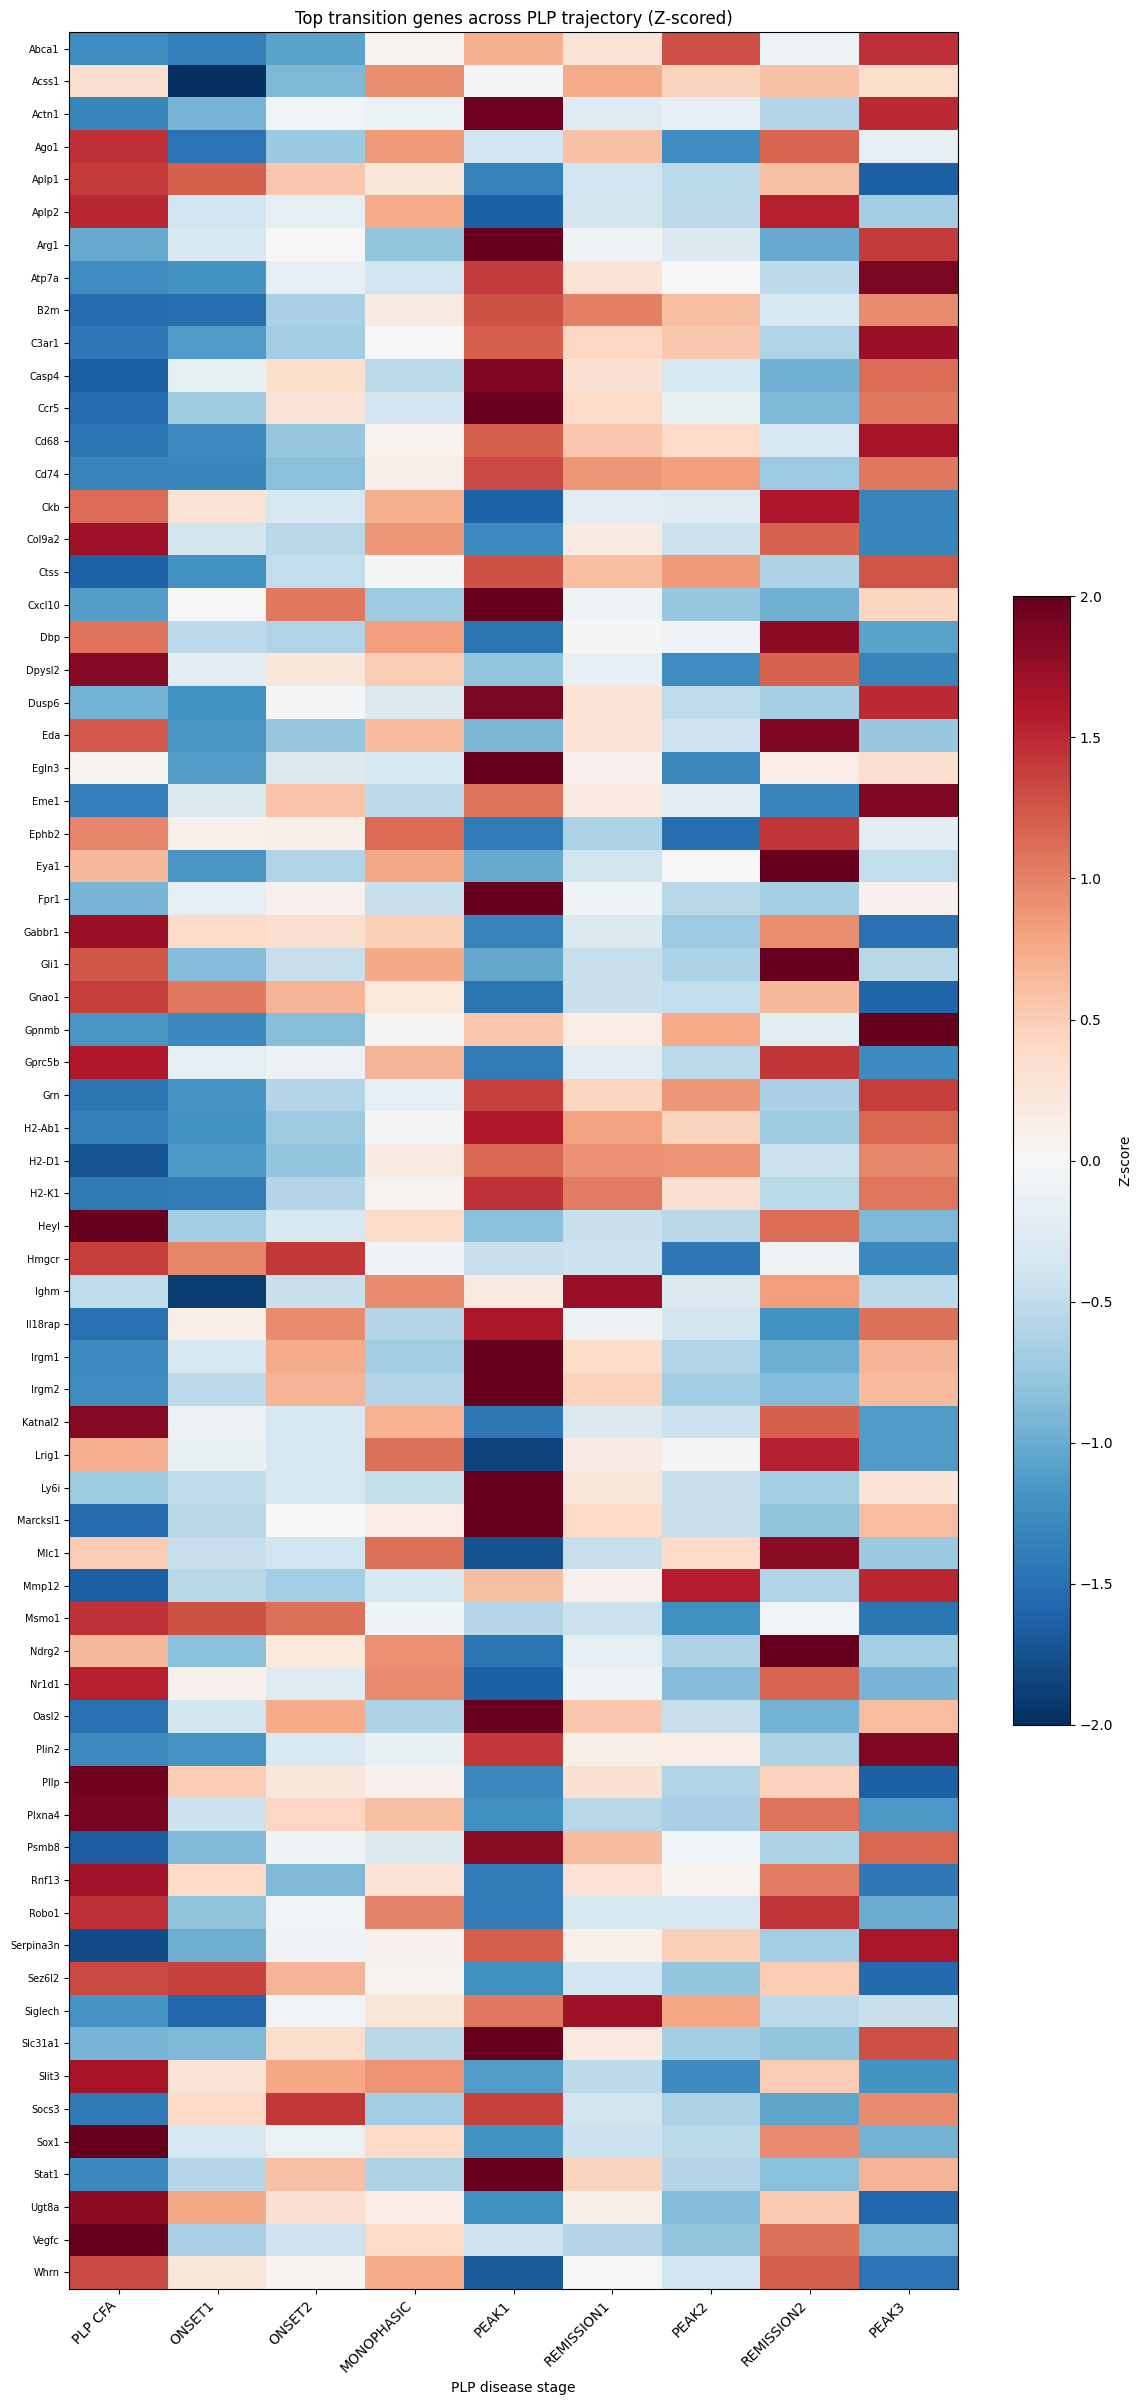

In [43]:
# Heatmap: mean expression per PLP stage (cell-level, from full dataset)
plp_full = adata_full[adata_full.obs['model_short'] == 'PLP'].copy()
sc.pp.normalize_total(plp_full, target_sum=1e4)
sc.pp.log1p(plp_full)

plp_stages = get_all_stages()['PLP']
gene_idx = [list(plp_full.var_names).index(g) for g in top_genes if g in plp_full.var_names]
top_genes_filtered = [plp_full.var_names[gi] for gi in gene_idx]

heatmap_data = np.zeros((len(top_genes_filtered), len(plp_stages)))
for j, stage in enumerate(plp_stages):
    mask = plp_full.obs[STAGE_KEY] == stage
    if mask.sum() > 0:
        X = plp_full[mask].X
        if sparse.issparse(X):
            heatmap_data[:, j] = np.asarray(X[:, gene_idx].mean(axis=0)).flatten()
        else:
            heatmap_data[:, j] = X[:, gene_idx].mean(axis=0)

# Z-score per gene
row_mean = heatmap_data.mean(axis=1, keepdims=True)
row_std = heatmap_data.std(axis=1, keepdims=True)
row_std[row_std == 0] = 1
heatmap_z = (heatmap_data - row_mean) / row_std

fig, ax = plt.subplots(figsize=(12, max(8, len(top_genes_filtered) * 0.35)))
im = ax.imshow(heatmap_z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_xticks(range(len(plp_stages)))
ax.set_xticklabels(plp_stages, rotation=45, ha='right')
ax.set_yticks(range(len(top_genes_filtered)))
ax.set_yticklabels(top_genes_filtered, fontsize=7)
ax.set_xlabel('PLP disease stage')
ax.set_title('Top transition genes across PLP trajectory (Z-scored)')
plt.colorbar(im, ax=ax, label='Z-score', shrink=0.5)
plt.tight_layout()
plt.show()


45 marker genes across 9 stages


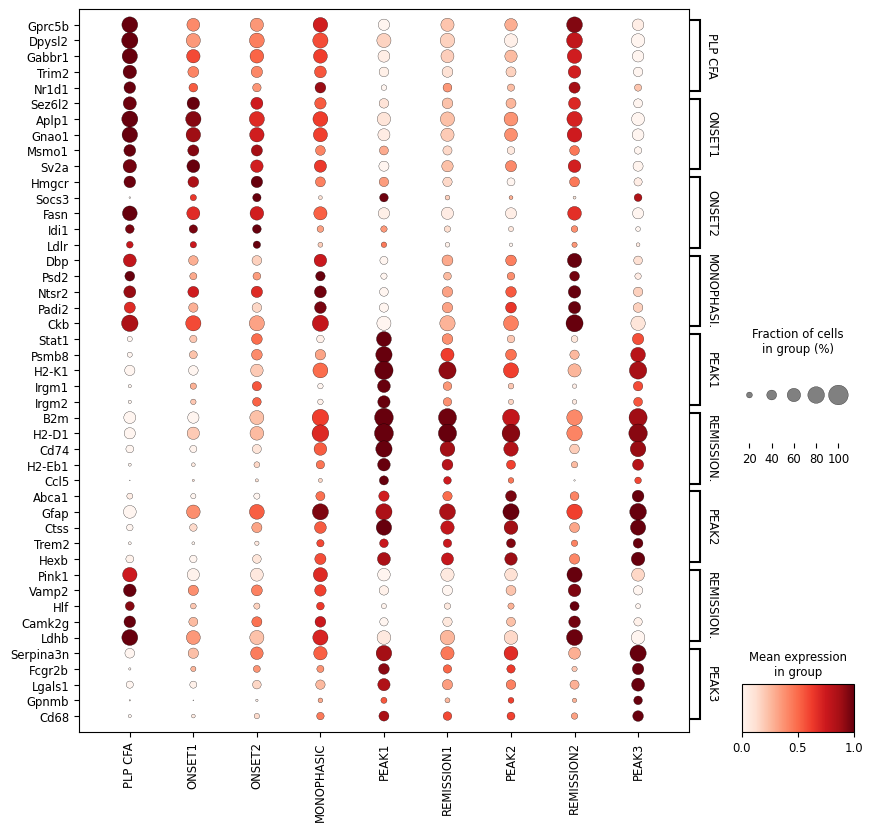

In [46]:
# Ordered dotplot: top markers per stage across the PLP trajectory
plp_stages = get_all_stages()['PLP']
N_PER_STAGE = 5

# Collect top N unique markers per stage, in trajectory order
gene_groups = {}  # stage -> [genes]
seen = set()

for stage in plp_stages:
    try:
        result = sc.get.rank_genes_groups_df(plp, group=stage)
        sig = result[result['pvals_adj'] < 0.05]
        stage_genes = []
        for _, row in sig.iterrows():
            if row['names'] not in seen:
                stage_genes.append(row['names'])
                seen.add(row['names'])
            if len(stage_genes) >= N_PER_STAGE:
                break
        if stage_genes:
            gene_groups[stage] = stage_genes
    except:
        pass

total = sum(len(v) for v in gene_groups.values())
print(f'{total} marker genes across {len(gene_groups)} stages')

sc.pl.dotplot(plp, var_names=gene_groups, groupby=STAGE_KEY,
              standard_scale='var', swap_axes=True,
              figsize=(10, total * 0.2),
              title='PLP trajectory: top stage marker genes')
plt.show()


Clock genes in panel: ['Dbp', 'Nr1d1', 'Hlf', 'Arntl', 'Clock', 'Per2', 'Cry1']


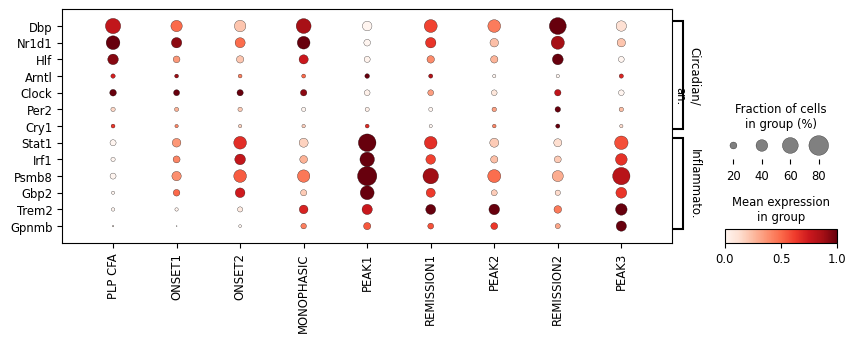


No time-of-day metadata found — cannot rule out sacrifice-time confound.
Check with the experimentalists what time animals were sacrificed.


In [55]:
# Circadian / anti-inflammatory gene trajectory
clock_genes = ['Dbp', 'Nr1d1', 'Hlf', 'Arntl', 'Clock', 'Per2', 'Cry1']
# Filter to genes present in the dataset
clock_present = [g for g in clock_genes if g in plp.var_names]
print(f'Clock genes in panel: {clock_present}')

# Also add the inflammatory markers for contrast
inflam_genes = ['Stat1', 'Irf1', 'Psmb8', 'Gbp2', 'Trem2', 'Gpnmb']
inflam_present = [g for g in inflam_genes if g in plp.var_names]

contrast_groups = {}
if clock_present:
    contrast_groups['Circadian/\nanti-inflammatory'] = clock_present
if inflam_present:
    contrast_groups['Inflammatory'] = inflam_present

if contrast_groups:
    sc.pl.dotplot(plp, var_names=contrast_groups, groupby=STAGE_KEY,
                  standard_scale='var', swap_axes=True,
                  figsize=(10, (len(clock_present) + len(inflam_present)) * 0.2))
    plt.show()

# Check if sacrifice time metadata exists
time_cols = [c for c in adata_full.obs.columns if any(kw in c.lower() for kw in ['time', 'hour', 'clock', 'zt', 'ct'])]
if time_cols:
    print(f'\nTime-related metadata columns found: {time_cols}')
    print('Check these to rule out sacrifice-time confound')
else:
    print(f'\nNo time-of-day metadata found — cannot rule out sacrifice-time confound.')
    print('Check with the experimentalists what time animals were sacrificed.')


### Circadian vs inflammatory programs: interpretation

The circadian output genes (`Dbp`, `Nr1d1`, `Hlf`) and the inflammatory genes
(`Stat1`, `Irf1`, `Psmb8`, `Gbp2`) show a clear **anti-correlated pattern**
across the PLP trajectory:

- **PEAK1** is the sharpest circadian disruption — `Dbp`/`Nr1d1`/`Hlf` essentially
  disappear. This is the IFN-gamma storm stage (`Stat1`, `Irf1` at maximum).
- **REMISSION1** is intermediate — circadian genes partially recover but inflammatory
  genes (`Psmb8`, `Stat1`) are still visible. Molecular armed truce, not true recovery.
- **REMISSION2** shows the strongest circadian recovery — `Dbp` and `Nr1d1` return
  to near-baseline levels. This is the deepest molecular remission.
- **PEAK3** suppresses circadian genes again, but less completely than PEAK1,
  consistent with a shift from acute IFN-gamma immunity to chronic foam cell
  pathology (`Trem2`, `Gpnmb` — a separate program that builds progressively).

**Why this is likely biological, not a sacrifice-time artifact**: the core clock
genes `Arntl` (BMAL1), `Clock`, `Per2`, and `Cry1` do not fluctuate as
dramatically. A time-of-day effect would suppress the entire clock uniformly.
The selective loss of the output/anti-inflammatory arm (`Dbp`, `Nr1d1`, `Hlf`)
while the core oscillator persists is the expected signature of **NF-kB-mediated
clock disruption** — inflammatory signaling suppresses clock output without
destroying the oscillator itself.

`Nr1d1` (Rev-Erb-alpha) is particularly relevant: it is both a clock component
and a direct repressor of inflammatory gene expression in macrophages.
Rev-Erb-alpha agonists have been shown to reduce EAE severity in mice.
Its restoration at remission may reflect active re-engagement of
anti-inflammatory circadian programs, not just passive resolution of
inflammation.
